Model : Air Quaity Identifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.impute import SimpleImputer

In [3]:
air_quality=pd.read_excel(r"D:\Machine learn\Project file\Air-quality\Air_quality-Repo\AirQualityUCI.xlsx")

In [4]:
air_quality

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [5]:
air_quality.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [6]:
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

In [7]:
air_quality.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [8]:
print((air_quality == -200).sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [9]:
air_quality.replace(-200,np.nan,inplace=True)

In [10]:
air_quality.isnull().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [11]:
print(f"Missing:\n{(air_quality.isnull().sum()/len(air_quality))*100}")

Missing:
Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
C6H6(GT)          3.911510
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64


In [12]:
air_quality.drop(columns="NMHC(GT)",inplace=True)

In [13]:
air_quality.isnull().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [14]:
air_quality['hour'] = air_quality['Time'].apply(lambda x : x.hour)
air_quality['minute'] = air_quality['Time'].apply(lambda x : x.minute)
air_quality['second'] = air_quality['Time'].apply(lambda x : x.second)

In [15]:
air_quality

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,minute,second
0,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754,18,0,0
1,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487,19,0,0
2,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239,20,0,0
3,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713,21,0,0
4,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794,22,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824,10,0,0
9353,2005-04-04,11:00:00,2.4,1162.50,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864,11,0,0
9354,2005-04-04,12:00:00,2.4,1142.00,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649,12,0,0
9355,2005-04-04,13:00:00,2.1,1002.50,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866,13,0,0


In [16]:
print(air_quality["hour"].unique())
print(air_quality["minute"].unique())
print(air_quality["second"].unique())

[18 19 20 21 22 23  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
[0]
[0]


In [17]:
air_quality.drop(columns = ["minute","second"],inplace = True)
air_quality.drop(columns = ["Date","Time"],inplace = True)

In [18]:
air_quality.isnull().sum()

CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
hour                0
dtype: int64

In [19]:
air_quality.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'hour'],
      dtype='object')

In [20]:
air_quality.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour
count,7674.000000,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357.000000
mean,2.152750,1099.707856,10.082993,939.029205,246.881252,835.370973,113.075515,1456.143486,1022.780725,18.316054,49.232360,1.025530,11.498557
std,1.453252,217.084571,7.449640,266.829000,212.971224,256.815106,48.359250,346.204540,398.480897,8.832888,17.316389,0.403813,6.923182
min,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679,0.000000
25%,1.100000,936.750000,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769,5.000000
50%,1.800000,1063.000000,8.239851,909.000000,179.800000,805.500000,109.000000,1462.750000,963.250000,17.750000,49.550000,0.995395,11.000000
75%,2.900000,1231.250000,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701,18.000000
max,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036,23.000000


In [21]:
# Target 
y = air_quality['CO(GT)']

# Feature
x = air_quality.drop(['CO(GT)','NOx(GT)','NO2(GT)'],axis=1)

In [22]:
# split data as train and test
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [23]:
corr_df = x_train.copy()
corr_df['CO(GT)'] = y_train
corr_df.corr()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour,CO(GT)
PT08.S1(CO),1.000000,0.883857,0.893357,-0.772945,0.680065,0.899229,0.047980,0.113016,0.132857,0.322101,0.879635
C6H6(GT),0.883857,1.000000,0.982099,-0.734943,0.762657,0.863811,0.198068,-0.062916,0.165608,0.339685,0.927616
PT08.S2(NMHC),0.893357,0.982099,1.000000,-0.795845,0.774185,0.879018,0.239914,-0.091505,0.183693,0.385368,0.913980
PT08.S3(NOx),-0.772945,-0.734943,-0.795845,1.000000,-0.536071,-0.796637,-0.139878,-0.059230,-0.227312,-0.318814,-0.704483
PT08.S4(NO2),0.680065,0.762657,0.774185,-0.536071,1.000000,0.584577,0.561994,-0.030608,0.630530,0.219238,0.623781
PT08.S5(O3),0.899229,0.863811,0.879018,-0.796637,0.584577,1.000000,-0.029376,0.121409,0.065406,0.241486,0.853704
T,0.047980,0.198068,0.239914,-0.139878,0.561994,-0.029376,1.000000,-0.576496,0.655130,0.206238,0.017990
RH,0.113016,-0.062916,-0.091505,-0.059230,-0.030608,0.121409,-0.576496,1.000000,0.171902,-0.295230,0.045505
AH,0.132857,0.165608,0.183693,-0.227312,0.630530,0.065406,0.655130,0.171902,1.000000,-0.019291,0.042773
hour,0.322101,0.339685,0.385368,-0.318814,0.219238,0.241486,0.206238,-0.295230,-0.019291,1.000000,0.353083


<Axes: >

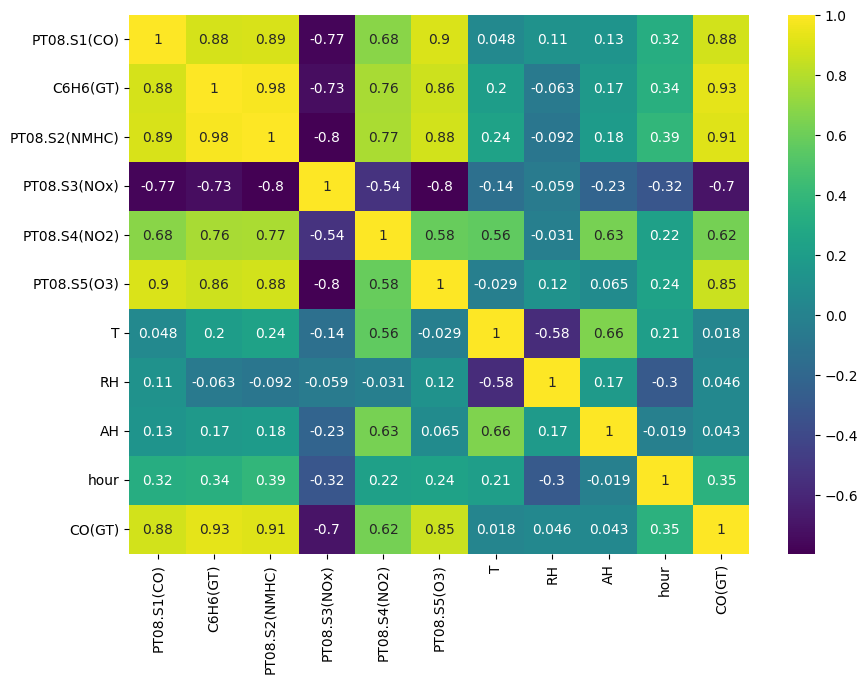

In [24]:
fig,ax = plt.subplots(figsize = (10,7))
sbn.heatmap(corr_df.corr(), annot = True, cmap = 'viridis')

In [25]:
imputer = SimpleImputer(strategy='median')
imput_train = pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns,index=x_train.index)
imput_test = pd.DataFrame(imputer.fit_transform(x_test),columns=x_test.columns,index=x_test.index)

In [26]:
imput_train.isnull().sum()

PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
hour             0
dtype: int64

In [27]:
imput_test.isnull().sum()

PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
hour             0
dtype: int64

In [28]:
y_train.isnull().sum()

np.int64(1355)

In [29]:
y_test.isnull().sum()

np.int64(328)

In [30]:
median = y_train.median()
print(f" Meadian value From y_train : {median}")

 Meadian value From y_train : 1.8


In [31]:
y_train.fillna(median,inplace=True)

In [32]:
y_train.isna().sum()

np.int64(0)

In [33]:
y_train

4367    3.4
794     1.2
8496    1.2
3027    2.9
8508    0.3
       ... 
5734    1.8
5191    1.8
5390    3.6
860     4.0
7270    3.8
Name: CO(GT), Length: 7485, dtype: float64

In [34]:
y_test.fillna(median,inplace=True)


In [35]:
y_test.isnull().sum()

np.int64(0)

In [36]:
reg = LinearRegression()

In [37]:
reg.fit(imput_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
list(zip(imput_train.columns,reg.coef_))

[('PT08.S1(CO)', np.float64(0.0009606020331441563)),
 ('C6H6(GT)', np.float64(0.11352164605918674)),
 ('PT08.S2(NMHC)', np.float64(-0.0002444093767574937)),
 ('PT08.S3(NOx)', np.float64(0.00010885917921492146)),
 ('PT08.S4(NO2)', np.float64(-5.60328065487309e-05)),
 ('PT08.S5(O3)', np.float64(0.0004084774597125958)),
 ('T', np.float64(-0.0064540656190526175)),
 ('RH', np.float64(0.004334418801368345)),
 ('AH', np.float64(-0.24019425671498715)),
 ('hour', np.float64(0.01684663352986923))]

In [39]:
print(F"Intercept : {reg.intercept_}")

Intercept : -0.34426638459306025


In [ ]:
# MOdel Prediction

reg_predi = reg.predict(imput_test)
print(F"Prediction : {reg_predi}")

Prediction : [1.3381981  1.04888926 2.91366315 ... 1.23363101 2.38758708 1.83628341]


In [ ]:
# MSE Score

mse = mean_squared_error(y_test,reg_predi)
print(F"prediction value : {mse}")

prediction value : 0.5352314771579295


In [42]:
pre_trian = reg.predict(imput_train)
pre_test = reg.predict(imput_test)

In [ ]:
#R2_Score

print(f"R-Squar error:{r2_score(y_train,pre_trian)}")
print(f"R-Squar error:{r2_score(y_test,pre_test)}")

R-Squar error:0.6912539149918315
R-Squar error:0.7146334037693653


In [ ]:
# RMSE Score

Rmse = mse ** 0.5
print(F"RMSE is : {Rmse}")

RMSE is : 0.731595159331942


In [45]:
# MAE Score

mae = mean_absolute_error(y_test,reg_predi)
print(F"mean absolute error : {mae}")

mean absolute error : 0.4617344264290254


In [ ]:
# Result

result = pd.DataFrame({
    "Actual":y_test.values,
    "prediction":reg_predi
})

print(f"Model Result Is : {result}")

Model Result Is :       Actual  prediction
0        1.3    1.338198
1        1.8    1.048889
2        2.6    2.913663
3        3.1    2.865971
4        1.3    1.579394
...      ...         ...
1867     2.4    2.013330
1868     3.0    2.968893
1869     1.0    1.233631
1870     2.4    2.387587
1871     1.8    1.836283

[1872 rows x 2 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

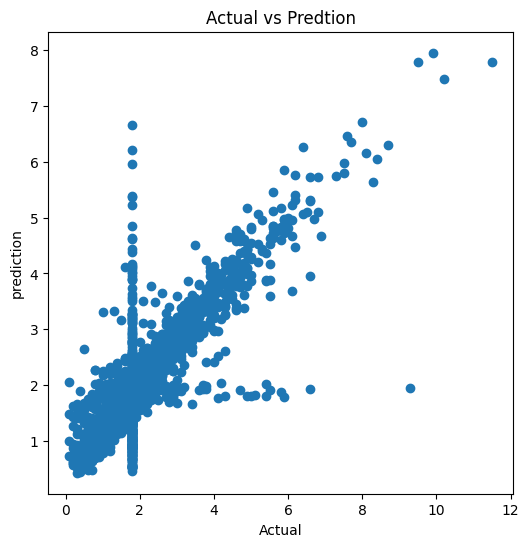

In [ ]:
# plot

plt.figure(figsize=(6,6))
plt.scatter(y_test,reg_predi)

plt.xlabel("Actual")
plt.ylabel("prediction")
plt.title("Actual vs Predtion")

plt.legend
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

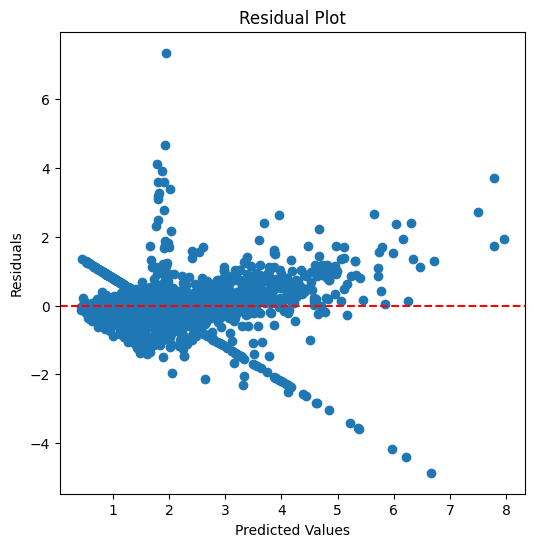

In [50]:
# Residual Plot
residual = y_test - reg_predi

plt.figure(figsize=(6,6))
plt.scatter(reg_predi,residual)
plt.axhline(y = 0 , color='red', linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.legend
plt.show